# AF-CALVADOS (CECAM version)

This colab runs single-chain simulations with AF-CALVADOS and performs basic analysis of the resulting trajectory. The data and figures can be downloaded at the bottom of the notebook.

If you use AF-CALVADOS, please cite:

S. von Buelow, K. E. Johansson, K. Lindorff-Larsen AF-CALVADOS: AlphaFold-guided simulations of multi-domain proteins at the proteome level bioRxiv 2025

More complex simulations can be run locally with the CALVADOS package. An example for running AF-CALVADOS within the CALVADOS package can be found [here](
https://github.com/KULL-Centre/CALVADOS/tree/main/examples/single_AF_CALVADOS).

# Import and functions

In [ ]:
# @title
!pip install openmm[cuda12]
!pip install git+https://github.com/KULL-Centre/CALVADOS.git@colab_compatible
!pip install py3Dmol

import os
import calvados as cal
from calvados.cfg import Config, Job, Components, load_ebi
from calvados import sim
import subprocess
import numpy as np
import numba as nb
import math
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import MDAnalysis as mda
from MDAnalysis.coordinates.PDB import PDBWriter
from MDAnalysis.analysis import align

from io import StringIO
import json
import requests
from pathlib import Path

import py3Dmol

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams['font.size'] = 6
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['ytick.minor.size'] = 1
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['xtick.minor.size'] = 1
plt.rcParams['xtick.labelsize'] = 6
plt.rcParams['ytick.labelsize'] = 6
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['axes.labelpad'] = 2
plt.rcParams['savefig.pad_inches'] = 0.1
plt.rcParams['figure.dpi'] = 300
plt.rcParams['lines.markersize'] = 3
plt.rcParams['lines.markeredgewidth'] = 0.5
plt.rcParams['lines.linewidth'] = 1.
plt.rcParams['figure.max_open_warning'] = 30

col1x = 3.425 # column
col2x = 7. # 2x column

github_folder = 'https://raw.githubusercontent.com/KULL-Centre/CALVADOS/colab_compatible'

cwd = os.getcwd()

def load_pae(name, pdb_folder):
    input_pae = f'{pdb_folder}/{name}.json'
    pae = cal.build.load_pae(input_pae,symmetrize=True,colabfold=0) / 10. # nm
    return pae

def calc_rgs(name, path, start=10,stop=None,step=1):
    u = mda.Universe(f'{path}/top.pdb',f'{path}/{name}.dcd')
    ag = u.atoms
    rg = cal.analysis.calc_rg(u, ag, start=start, stop=stop, step=step)
    return rg

def calc_ees(name, path, start=10,stop=None,step=1):
    u = mda.Universe(f'{path}/top.pdb',f'{path}/{name}.dcd')
    ag = u.atoms
    ees, _, _ = cal.analysis.calc_ete(u,ag,start=start,stop=stop,step=step)
    return ees

def calc_timesteps(name, path, start=10, stop=None, step=1):
    u = mda.Universe(f'{path}/top.pdb',f'{path}/{name}.dcd')
    dt = u.trajectory[0].dt * step
    xs = np.arange(len(u.trajectory[start:stop:step])) * dt / 1000.
    return xs

def calc_dmap_std_manual(name, path, start=10,stop=None,step=1):
    u = mda.Universe(f'{path}/top.pdb',f'{path}/{name}.dcd')
    ag = u.atoms

    box = u.dimensions[:3] / 10.
    coordinates = u.trajectory.timeseries(ag) / 10.

    nres = len(ag)

    dmap_std_manual = calc_dmap_std_numba(coordinates,box,nres,start=start,stop=stop,step=step)
    return dmap_std_manual

@staticmethod
@nb.jit(nopython=True)
def calc_dmap_std_numba(coordinates,box,nres,start=10,stop=None,step=1):
    dmaps_std_manual = np.zeros((nres,nres))

    for idx in range(nres):
        for jdx in range(idx,nres):
            x0 = coordinates[idx,start:stop:step]
            x1 = coordinates[jdx,start:stop:step]
            dvec = x1-x0
            dvec_pbc = np.where(dvec<=box/2, dvec, box-dvec)
            d = np.zeros((len(x0)))
            for kdx, dv_pbc in enumerate(dvec_pbc):
                d[kdx] = math.sqrt(dv_pbc[0]**2 + dv_pbc[1]**2 + dv_pbc[2]**2)
            d_std = np.std(d)

            dmaps_std_manual[idx,jdx] = d_std
            dmaps_std_manual[jdx,idx] = d_std
    return dmaps_std_manual

def load_plddt(name, pdb_folder):
    # pLDDT
    pdb = f'{pdb_folder}/{name}.pdb'
    plddt = cal.build.bfac_from_pdb(pdb)
    # bfac_matrix = np.minimum.outer(bfac,bfac)
    return plddt

################

def plot_rg(name, path, start=10, stop=None, step=1):
    rgs = calc_rgs(name, path, start=start,stop=stop,step=step)
    fig, ax = plt.subplots(1,2,figsize=(3,1.2))

    xs = calc_timesteps(name, path, start=start)
    ax[0].plot(xs, rgs)
    ax[0].set(xlim=(xs[0],xs[-1]))
    ax[0].set(xlabel='Time [ns]', ylabel=r'$R_\mathrm{g}$ [nm]')

    ax[1].hist(rgs,bins=50,histtype='step',color='C0',density=True)
    ax[1].hist(rgs,bins=50,alpha=0.3,color='C0',density=True)
    ax[1].set(xlabel=r'$R_\mathrm{g}$ [nm]', ylabel='pdf')

    fig.tight_layout()
    os.makedirs(f'{name}/analysis',exist_ok=True)
    np.savetxt(f'{name}/analysis/{name}_rg.txt', rgs.T)
    fig.savefig(f'{name}/analysis/{name}_rg.pdf')

def plot_ee(name, path, start=10, stop=None, step=1):
    # rgs = calc_rgs(name, path, start=10,stop=None,step=1)
    ees = calc_ees(name, path, start=start,stop=stop,step=step)
    fig, ax = plt.subplots(1,2,figsize=(3,1.2))

    xs = calc_timesteps(name, path, start=start)
    ax[0].plot(xs, ees)
    ax[0].set(xlim=(xs[0],xs[-1]))
    ax[0].set(xlabel='Time [ns]', ylabel=r'$R_\mathrm{ee}$ [nm]')

    ax[1].hist(ees,bins=50,histtype='step',color='C0',density=True)
    ax[1].hist(ees,bins=50,alpha=0.3,color='C0',density=True)
    ax[1].set(xlabel=r'$R_\mathrm{ee}$ [nm]', ylabel='pdf')

    fig.tight_layout()
    os.makedirs(f'{name}/analysis',exist_ok=True)
    np.savetxt(f'{name}/analysis/{name}_ree.txt', ees.T)
    fig.savefig(f'{name}/analysis/{name}_ree.pdf')

def plot_plddt(name, pdb_folder):
    seq = cal.sequence.seq_from_pdb(f'{pdb_folder}/{name}.pdb')[0]
    print(seq)
    nres = len(seq)
    xs = np.arange(1,nres+1)

    plddt = load_plddt(name, pdb_folder)
    fig, ax = plt.subplots(figsize=(3,1.5))
    ax.plot(xs, plddt*100)
    ax.set(xlim=(xs[0],xs[-1]))
    ax.set(xlabel='Residue', ylabel='pLDDT')
    fig.tight_layout()
    os.makedirs(f'{name}/analysis',exist_ok=True)
    with open(f'{name}/analysis/{name}_pLDDT.txt','w') as f:
        for x, pl in zip(xs, plddt):
            f.write(f'{x} {pl}\n')
    fig.savefig(f'{name}/analysis/{name}_pLDDT.pdf')

def plot_pae(name, pdb_folder):
    pae = load_pae(name, pdb_folder)
    nres = len(pae)
    fig, ax = plt.subplots(figsize=(2.2,2.2))
    axij_pae = ax
    _ = axij_pae.imshow(pae,cmap=plt.cm.Oranges_r,vmin=0,vmax=3.)

    divider = make_axes_locatable(axij_pae)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    # plt.colorbar(im, cax=cax)
    plt.colorbar(_,cax=cax,label='nm')

    axij_pae.set_title(f'{name}\nPAE', fontsize=6, linespacing=1.5)

    for a in [axij_pae]:
        a.grid(False)
        a.set(xlabel='Residue',ylabel='Residue')
    fig.tight_layout()

def plot_pae_sigma(name, path, pdb_folder, start=10, stop=None, step=1):
    pae = load_pae(name, pdb_folder)
    nres = len(pae)
    fig, ax = plt.subplots(1,2,figsize=(4,2.2))
    axij_pae = ax[0]
    _ = axij_pae.imshow(pae,cmap=plt.cm.Oranges_r,vmin=0,vmax=3.)

    divider = make_axes_locatable(axij_pae)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    # plt.colorbar(im, cax=cax)
    plt.colorbar(_,cax=cax,label='nm')

    axij_pae.set_title(f'{name}\nPAE', fontsize=6, linespacing=1.5)

    xs = np.arange(0,nres,100)

    cmap = plt.cm.Blues_r

    dmaps_std = calc_dmap_std_manual(name, path, start=start, stop=stop, step=step)

    axij_dmaps = ax[1]

    _ = axij_dmaps.imshow(dmaps_std,cmap=cmap,vmin=0,vmax=2)
    axij_dmaps.set_title(f'{name}\n'+r'$\sigma(r)$ Sim.', fontsize=6, linespacing=1.5)
    divider = make_axes_locatable(axij_dmaps)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    # plt.colorbar(im, cax=cax)
    plt.colorbar(_,cax=cax,label='nm')

    for a in [axij_pae, axij_dmaps]:
        a.grid(False)
        a.set(xlabel='Residue',ylabel='Residue')
    fig.tight_layout()
    os.makedirs(f'{name}/analysis',exist_ok=True)
    np.save(f'{name}/analysis/{name}_PAE.npy', pae)
    np.save(f'{name}/analysis/{name}_sigma.npy', dmaps_std)
    fig.savefig(f'{name}/analysis/{name}_PAE_vs_sigma.pdf')

##############

def set_up_system(
    name,
    path,
    temp,
    ionic,
    pH,
    L,
    N_save,
    N_frames,
    pdb_folder,
    fresidues,
    epsilon = 15.,
    plddt_shift = 0.8,
    plddt_slope = 50.,
    pae_shift = 0.3,
    pae_slope = 15.,
):
    config = Config(
      # GENERAL
      sysname = name, # name of simulation system
      box = [L, L, L], # nm
      temp = temp, # 20 degrees Celsius
      ionic = ionic, # molar
      pH = pH, # 7.5
      topol = 'center',

      # RUNTIME SETTINGS
      wfreq = N_save, # dcd writing interval, 1 = 10 fs
      steps = N_frames*N_save, # number of simulation steps
      runtime = 0, # overwrites 'steps' keyword if > 0
      platform = 'CUDA', # or CUDA
      restart = None,
      frestart = 'restart.chk',
      verbose = True,
    )

    # PATH
    subprocess.run(f'mkdir -p {path}',shell=True)

    config.write(path,name='config.yaml')

    components = Components(
      # Defaults
      molecule_type = 'protein',
      nmol = 1, # number of molecules
      restraint = True, # apply restraints
      charge_termini = 'both', # charge N or C or both

      # INPUT
      fresidues = fresidues, # residue definitions
      pdb_folder = pdb_folder, # directory for pdb and PAE files

      # RESTRAINTS
      restraint_type = 'go', # harmonic or go
      use_com = True, # apply on centers of mass instead of CA
      colabfold = 0, # PAE format (EBI AF=0, Colabfold=1&2)
      k_go = epsilon, # Restraint force constant
      bfac_shift = plddt_shift,
      bfac_width = plddt_slope,
      pae_shift = pae_shift,
      pae_width = pae_slope,
    )
    components.add(name=name)
    components.write(path,name='components.yaml')

####################

ALPHAFOLD_API = "https://alphafold.ebi.ac.uk/api/prediction"

def write_entry(uniprot, entry, pdb_folder):
    out = Path(pdb_folder) / f"{uniprot}_info.json"
    with open(out, 'w') as f:
        json.dump(entry, f, indent=2)

def download_file(url, dest):
    r = requests.get(url, allow_redirects=True)
    r.raise_for_status()
    with open(dest, 'wb') as f:
        f.write(r.content)

def load_ebi(uniprot, pdb_folder):
    folder = Path(pdb_folder)
    folder.mkdir(parents=True, exist_ok=True)

    # Fetch entry metadata
    r = requests.get(f"{ALPHAFOLD_API}/{uniprot}")
    r.raise_for_status()
    results = r.json()

    if not results:
        raise ValueError(f"No AlphaFold entry found for UniProt ID: {uniprot}")

    entry = results[0]

    # Download PDB structure
    pdb_url = entry.get("pdbUrl")
    if not pdb_url:
        raise KeyError(f"'pdbUrl' not found in API response for {uniprot}")
    download_file(pdb_url, folder / f"{uniprot}.pdb")

    # Download PAE JSON — prefer new field, fall back to deprecated one
    pae_url = entry.get("paeDocUrl")
    if not pae_url:
        raise KeyError(f"No PAE doc URL found in API response for {uniprot}")
    download_file(pae_url, folder / f"{uniprot}.json")

    # Save full entry metadata
    write_entry(uniprot, entry, pdb_folder)
    print(f"Done: {uniprot}")

##############


def align_traj(pdb, traj, start=None, stop=None, step=1, reference_frame=0):
    """RMSD-align trajectory to a reference frame and write a new DCD"""

    u = mda.Universe(pdb, traj)

    # Reference structure (usually first frame)
    ref = mda.Universe(pdb, traj)
    ref.trajectory[reference_frame]

    with mda.Writer(f"{traj[:-4]}_aligned.dcd", len(u.atoms)) as W:
        for ts in u.trajectory[start:stop:step]:
            # Align current frame to reference
            align.alignto(u, ref, select="all")
            W.write(u.atoms)

#########

def postprocess_traj(name, path, step_view = 10):
    cal.analysis.center_traj(f'{path}/top.pdb', f'{path}/{name}.dcd', start=10)
    align_traj(f'{path}/top.pdb', f'{path}/{name}_c.dcd')

    u = mda.Universe(f'{path}/top.pdb', f'{path}/{name}_c_aligned.dcd')

    nres = len(u.atoms)
    models = []
    pdb_io = StringIO()

    with mda.Writer('tmp.pdb', multiframe=True, format='pdb') as W:
        for ts in u.trajectory[::step_view]:
            W.write(u.atoms)
    return nres

def visualize(nres):
    cmap = plt.cm.viridis
    view = py3Dmol.view(width=800, height=600)
    with open('tmp.pdb', 'r') as f:
        pdb_str = f.read()
        view.addModelsAsFrames(pdb_str)

    view.setStyle({"sphere": {}})
    for idx in range(nres):
        color = np.array(cmap(idx/nres)[:3])*255
        colorstr = f'rgb({color[0]}, {color[1]}, {color[2]})'
        view.setStyle({"serial": [idx+1]}, {"sphere": {"color": colorstr}})

    view.zoomTo()
    view.animate({"loop": "forward"})
    view.show()

# Intro

This notebook demonstrates the effect of restraining parameter choice for AF-CALVADOS simulations.

We first run a simulation of the full-length Transcription elongation factor A protein 3 (Uniprot ID: O75764) with standard AF-CALVADOS parameters. We then see how the choice of restraining parameters affects the resulting ensemble.

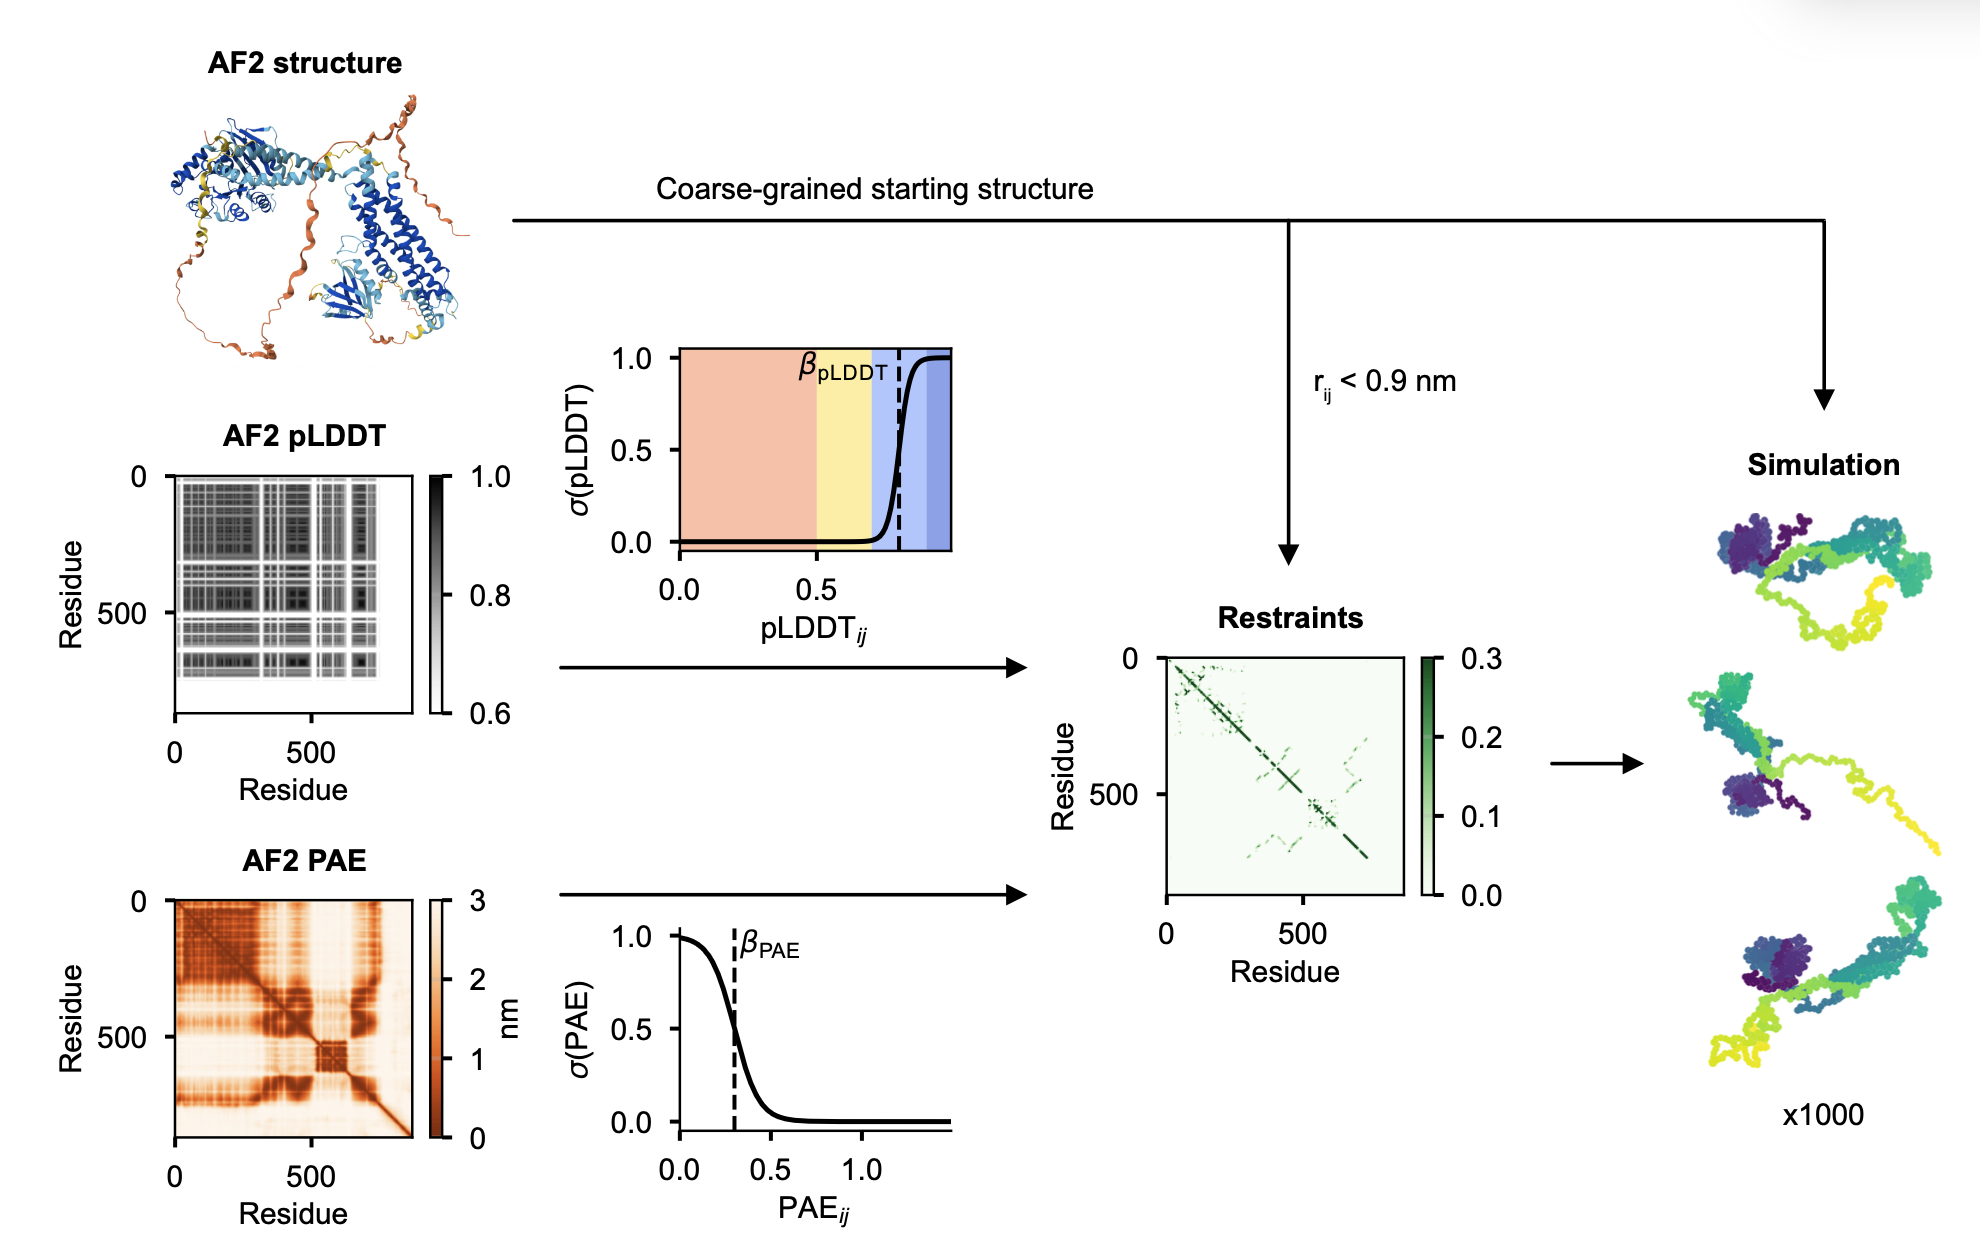

# Select protein

Select an Uniprot ID from the [AlphaFold2 EBI database](https://alphafold.ebi.ac.uk/).

In [ ]:
name = 'O75764' #@param {type:"string"}

os.makedirs(f'{cwd}/{name}/input',exist_ok=True)
os.system(f'wget -O {name}/input/residues.csv {github_folder}/examples/single_AF_CALVADOS/input/residues.csv')

pdb_folder = f'{cwd}/{name}/input'
fresidues = f'{cwd}/{name}/input/residues.csv'

path = f'{cwd}/{name}/simulation'

load_ebi(name, pdb_folder)

print(f'Check out the input structure at https://alphafold.ebi.ac.uk/entry/AF-{name}-F1')

Check out the input structure (link in output of previous cell). Which parts of the protein would you restrain to stay folded in a simulation?

## pLDDT plot

The pLDDT plot shows the [AF2 local confidence](https://www.ebi.ac.uk/training/online/courses/alphafold/inputs-and-outputs/evaluating-alphafolds-predicted-structures-using-confidence-scores/plddt-understanding-local-confidence/), which we here take as a proxy for order versus disorder.

> The predicted local distance difference test (pLDDT) is a per-residue measure of local confidence. It is scaled from 0 to 100, with higher scores indicating higher confidence and usually a more accurate prediction.
pLDDT measures confidence in the local structure, estimating how well the prediction would agree with an experimental structure.

The parameters `plddt_shift` and `plddt_slope` below affect the restraints based on the pLDDT values plotted here.

In [ ]:
plot_plddt(name, pdb_folder)

## PAE plot

The PAE plot shows the [PAE matrix](https://www.ebi.ac.uk/training/online/courses/alphafold/inputs-and-outputs/evaluating-alphafolds-predicted-structures-using-confidence-scores/pae-a-measure-of-global-confidence-in-alphafold-predictions/).


> A low PAE score between two residues from two different domains means low predicted error. This in turn means AlphaFold2 is confident in the position of these residues. Conversely, a high PAE score means that AlphaFold2 is not confident in their relative position.

The parameters `pae_shift` and `pae_slope` affect the restraints based on the PAE matrix plotted here.

In [ ]:
plot_pae(name, pdb_folder)

# Simulation setup

We first run a short coarse-grained simulation of O75764 with default AF-CALVADOS settings. These have been optimized to match experimental SAXS data.

- `epsilon` is the overall strength of the restraints in kJ/mol
- `plddt_shift` is the midpoint of the switching function mapping [pLDDT values](https://www.ebi.ac.uk/training/online/courses/alphafold/inputs-and-outputs/evaluating-alphafolds-predicted-structures-using-confidence-scores/plddt-understanding-local-confidence/) (divided by 100) to restraints
- `plddt_slope` is the steepness of the switching function. A very high `plDDT_slope` value switches the pLDDT contribution to restraints on and off in a binary way, whereas a lower value leads to more gradual switching.
- `pae_shift` is the midpoint of the switching function mapping [PAE values](https://www.ebi.ac.uk/training/online/courses/alphafold/inputs-and-outputs/evaluating-alphafolds-predicted-structures-using-confidence-scores/pae-a-measure-of-global-confidence-in-alphafold-predictions/) (in nm) to restraints
- `pae_slope` is the steepness of the switching function. A very high `pae_slope` value switches the PAE contribution to restraints on and off in a binary way, whereas a lower value leads to more gradual switching.

In [ ]:

temp = 293 #@param {type:"number"}
ionic = 0.15 #@param {type:"number"}
pH = 7.5 #@param {type:"number"}

epsilon = 15 #@param {type:"number"}
plddt_shift = 0.8 #@param {type:"number"}
plddt_slope = 50. #@param {type:"number"}
pae_shift = 0.3 #@param {type:"number"}
pae_slope = 15. #@param {type:"number"}

step_size_ns = 0.01 #@param {type:"number", label:"Step size [ns]"}
sim_length_ns = 20 #@param {type:"number", label:"Simulation length [ns]"}

# set the side length of the cubic box
L = 80

# set the saving interval (number of integration steps)
N_save = int(step_size_ns * 100 * 1000)
N_frames = int(sim_length_ns / step_size_ns)

print(f'wfreq: {N_save}, frames: {N_frames}')

N_frames += 10


set_up_system(
    name,
    path,
    temp,
    ionic,
    pH,
    L,
    N_save,
    N_frames,
    pdb_folder,
    fresidues,
    epsilon = epsilon,
    plddt_shift = plddt_shift,
    plddt_slope = plddt_slope,
    pae_shift = pae_shift,
    pae_slope = pae_slope,
)

# Run simulation

In [ ]:
sim.run(path=path,fconfig='config.yaml',fcomponents='components.yaml')

# Visualization

In [ ]:
nres = postprocess_traj(name, path)
visualize(nres)

# Analysis

## Plot Rg and end-to-end distance

In [ ]:
plot_rg(name, path)
plot_ee(name, path)

## Plot PAE vs pairwise distance fluctuations

The left plot shows the input PAE matrix from AlphaFold2.

The right plot shows the standard deviation $\sigma$ of residue pair distances $r$. Low values of $\sigma(r)$ indicate that the residue pair tumbles as one unit in solution (e.g. in one domain), whereas high values of $\sigma(r)$ indicate independent motion of the two residues.

In [ ]:
plot_pae_sigma(name, path, pdb_folder)

**Now go back to the start, modify `epsilon`, `plddt_shift` and `pae_shift` and run again.**

- `epsilon` tunes the overall strength of the restraints and influences overall domain stability and dynamics within the domain.
- Decreasing `plddt_shift` allows restraining of regions with less AF2 confidence; increased `plddt_shift` leads to restraining of only very confident regions.
- Decreasing `pae_shift` causes only the most coupled pairs (in AF2) to be restrained. Increasing `pae_shift` makes the algorithm more lenient for restraining less PAE-coupled pairs.

What results do you expect?

- How do radius of gyration and and end-to-end distance change?
- Compare the PAE matrix and $\sigma(r)$ for strongly restrained and weakly restrained simulations.

**Simulate different proteins**
- Try out different proteins (scroll through the [AlphaFold database](https://alphafold.ebi.ac.uk/)), for example the Zinc-finger protein REPIN1 (Q9BWE0).
What is the optimal parameter set that you would personally choose?
- The N-terminal 334 amino acids of the passenger domain of *Bordetella pertussis* pertactin is [unfolded *in vitro*](https://www.science.org/doi/10.1126/science.aan5774). Simulate pertactin (Uniprot ID: Q3YDW8) with AF-CALVADOS and compare to the experimental findings. What could be the reason for the findings?
